# Unified Bharat: Analytics & Panel Regression

Analysis on Gold State-Year Panel

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_squared_error, r2_score
import xgboost as xgb
import statsmodels.api as sm
from statsmodels.regression.linear_model import OLS
from linearmodels.panel import PanelOLS
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

# Load gold panel
df = pd.read_csv("/home/jovyan/data/gold/gold_state_year_panel.csv")
print(f"Panel shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
df.head()

Panel shape: (429, 17)
Columns: ['state_name', 'year', 'avg_csr_inr_crores', 'avg_csr_usd_millions', 'csr_spent_lag1', 'csr_per_capita_inr', 'hardness_avg', 'ph_avg', 'nitrate_avg', 'fluoride_avg', 'contamination_index', 'avg_approved_intake', 'avg_institutions', 'avg_total_approved_institutions', 'institutions_per_million', 'population_2024_estimate', 'panel_completeness']


,state_name,year,avg_csr_inr_crores,avg_csr_usd_millions,csr_spent_lag1,csr_per_capita_inr,hardness_avg,ph_avg,nitrate_avg,fluoride_avg,contamination_index,avg_approved_intake,avg_institutions,avg_total_approved_institutions,institutions_per_million,population_2024_estimate,panel_completeness
0,ANDAMAN & NICOBAR,2011,0.0,NaN,NaN,NaN,207.571429,7.774286,2.466667,0.186000,1.0,NaN,NaN,NaN,NaN,NaN,1
1,ANDAMAN & NICOBAR,2012,0.0,NaN,0.0,NaN,197.702703,8.210811,7.625000,0.143350,0.0,NaN,NaN,NaN,NaN,NaN,1
2,ANDAMAN & NICOBAR,2013,0.0,NaN,0.0,NaN,189.426230,7.937705,6.133455,0.339200,0.0,NaN,NaN,NaN,NaN,NaN,1
3,ANDAMAN & NICOBAR,2014,0.0,NaN,0.0,NaN,265.299352,8.022726,29.441892,0.657837,1.0,NaN,NaN,NaN,NaN,NaN,1
4,ANDAMAN & NICOBAR,2015,0.0,NaN,0.0,NaN,265.299352,8.022726,29.441892,0.657837,1.0,NaN,NaN,NaN,NaN,NaN,1


## 1. Exploratory Analysis

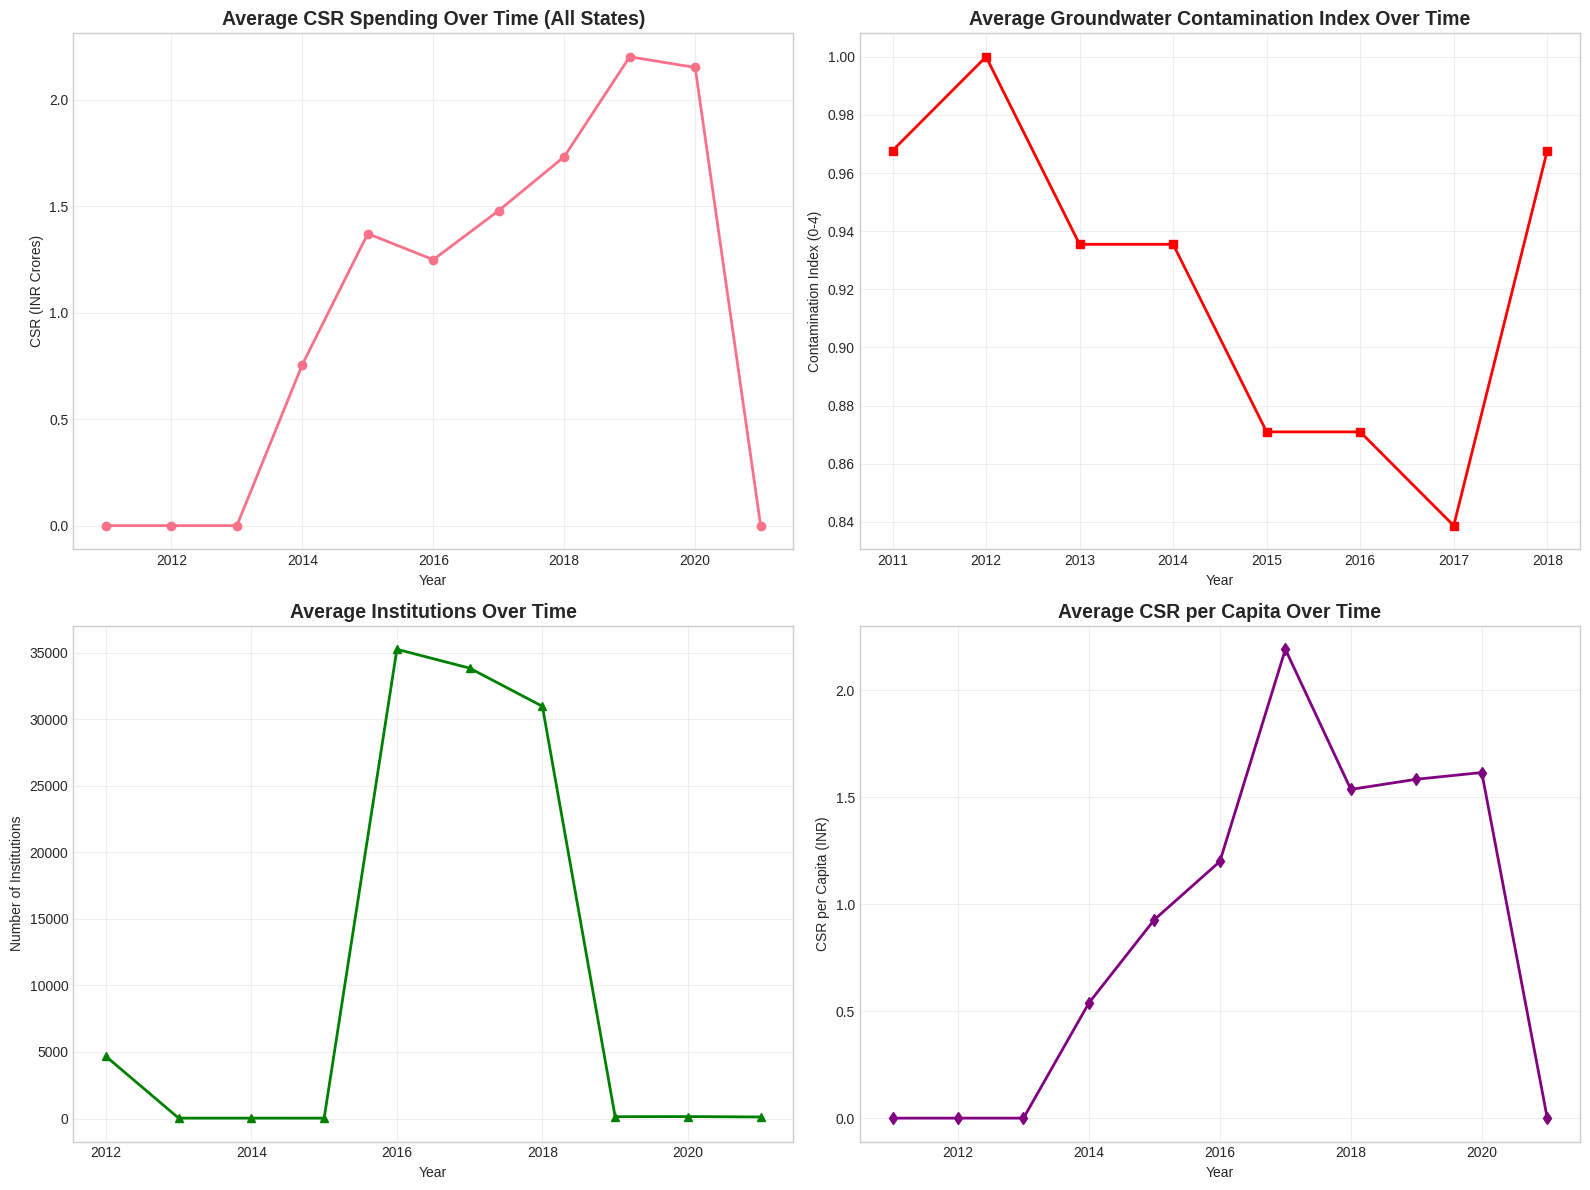

Temporal trends saved to temporal_trends.png


In [18]:
# Temporal Trends
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# CSR Trend
csr_trend = df.groupby('year')['avg_csr_inr_crores'].mean().reset_index()
axes[0,0].plot(csr_trend['year'], csr_trend['avg_csr_inr_crores'], marker='o', linewidth=2)
axes[0,0].set_title('Average CSR Spending Over Time (All States)', fontsize=14, fontweight='bold')
axes[0,0].set_xlabel('Year')
axes[0,0].set_ylabel('CSR (INR Crores)')
axes[0,0].grid(True, alpha=0.3)

# Contamination Trend
cont_trend = df.groupby('year')['contamination_index'].mean().reset_index()
axes[0,1].plot(cont_trend['year'], cont_trend['contamination_index'], marker='s', color='red', linewidth=2)
axes[0,1].set_title('Average Groundwater Contamination Index Over Time', fontsize=14, fontweight='bold')
axes[0,1].set_xlabel('Year')
axes[0,1].set_ylabel('Contamination Index (0-4)')
axes[0,1].grid(True, alpha=0.3)

# Institutions Trend
inst_trend = df.groupby('year')['avg_institutions'].mean().reset_index()
axes[1,0].plot(inst_trend['year'], inst_trend['avg_institutions'], marker='^', color='green', linewidth=2)
axes[1,0].set_title('Average Institutions Over Time', fontsize=14, fontweight='bold')
axes[1,0].set_xlabel('Year')
axes[1,0].set_ylabel('Number of Institutions')
axes[1,0].grid(True, alpha=0.3)

# CSR per Capita Trend
cap_trend = df.groupby('year')['csr_per_capita_inr'].mean().reset_index()
axes[1,1].plot(cap_trend['year'], cap_trend['csr_per_capita_inr'], marker='d', color='purple', linewidth=2)
axes[1,1].set_title('Average CSR per Capita Over Time', fontsize=14, fontweight='bold')
axes[1,1].set_xlabel('Year')
axes[1,1].set_ylabel('CSR per Capita (INR)')
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/home/jovyan/work/temporal_trends.png', dpi=300, bbox_inches='tight')
plt.show()
print("Temporal trends saved to temporal_trends.png")

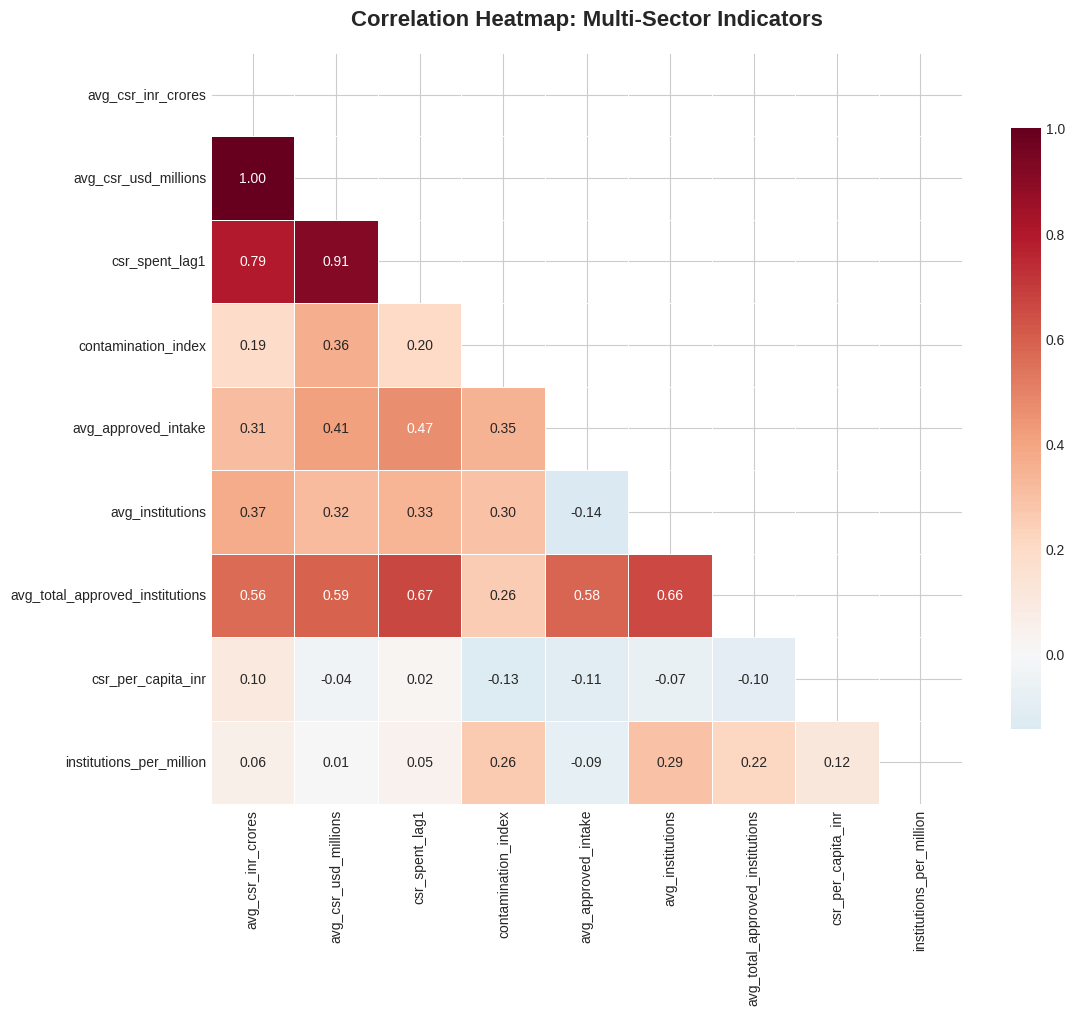

Correlation heatmap saved to correlation_heatmap.png


In [19]:
# Correlation Heatmap
numeric_cols = ['avg_csr_inr_crores', 'avg_csr_usd_millions', 'csr_spent_lag1',
                'contamination_index', 'avg_approved_intake',
                'avg_institutions', 'avg_total_approved_institutions',
                'csr_per_capita_inr', 'institutions_per_million']

corr_df = df[numeric_cols].corr()

plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_df, dtype=bool))
sns.heatmap(corr_df, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Correlation Heatmap: Multi-Sector Indicators', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('/home/jovyan/work/correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()
print("Correlation heatmap saved to correlation_heatmap.png")

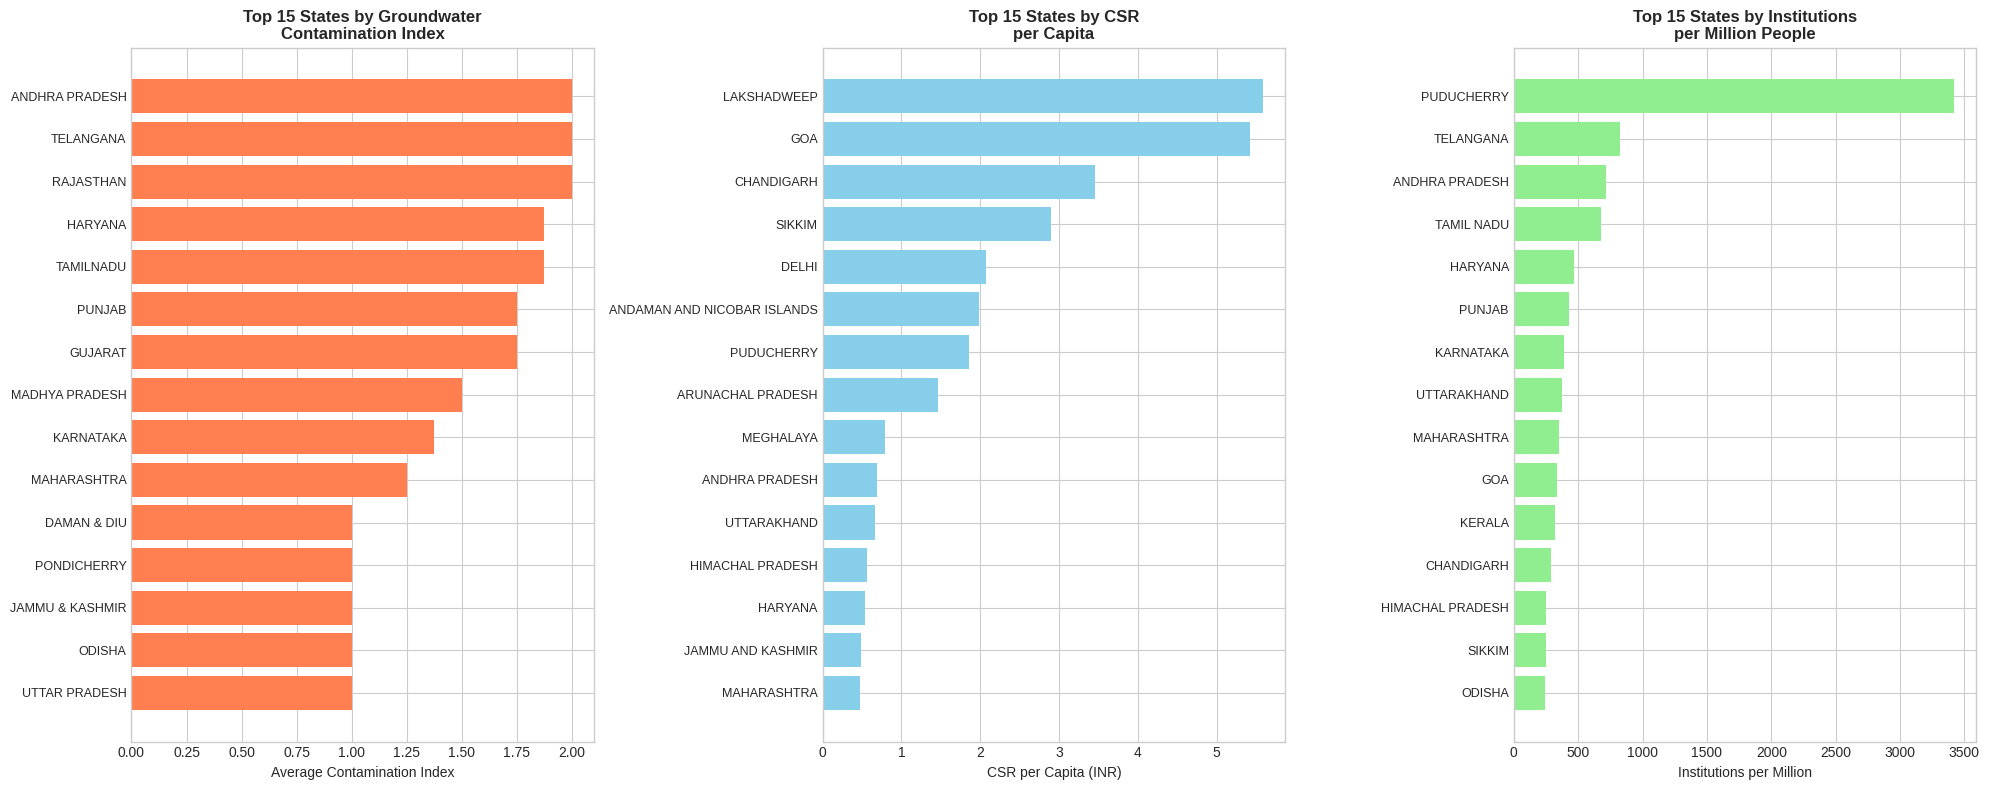

Spatial analysis saved to spatial_analysis.png


In [20]:
# Spatial Analysis - State Rankings (Bar charts as proxy for maps)
fig, axes = plt.subplots(1, 3, figsize=(20, 8))

# Average contamination by state
state_cont = df.groupby('state_name')['contamination_index'].mean().sort_values(ascending=False).head(15)
axes[0].barh(range(len(state_cont)), state_cont.values, color='coral')
axes[0].set_yticks(range(len(state_cont)))
axes[0].set_yticklabels(state_cont.index, fontsize=9)
axes[0].set_xlabel('Average Contamination Index')
axes[0].set_title('Top 15 States by Groundwater\nContamination Index', fontsize=12, fontweight='bold')
axes[0].invert_yaxis()

# Average CSR per capita by state
state_csr = df.groupby('state_name')['csr_per_capita_inr'].mean().sort_values(ascending=False).head(15)
axes[1].barh(range(len(state_csr)), state_csr.values, color='skyblue')
axes[1].set_yticks(range(len(state_csr)))
axes[1].set_yticklabels(state_csr.index, fontsize=9)
axes[1].set_xlabel('CSR per Capita (INR)')
axes[1].set_title('Top 15 States by CSR\nper Capita', fontsize=12, fontweight='bold')
axes[1].invert_yaxis()

# Institutions per million by state
state_inst = df.groupby('state_name')['institutions_per_million'].mean().sort_values(ascending=False).head(15)
axes[2].barh(range(len(state_inst)), state_inst.values, color='lightgreen')
axes[2].set_yticks(range(len(state_inst)))
axes[2].set_yticklabels(state_inst.index, fontsize=9)
axes[2].set_xlabel('Institutions per Million')
axes[2].set_title('Top 15 States by Institutions\nper Million People', fontsize=12, fontweight='bold')
axes[2].invert_yaxis()

plt.tight_layout()
plt.savefig('/home/jovyan/work/spatial_analysis.png', dpi=300, bbox_inches='tight')
plt.show()
print("Spatial analysis saved to spatial_analysis.png")

## 2. Clustering Analysis

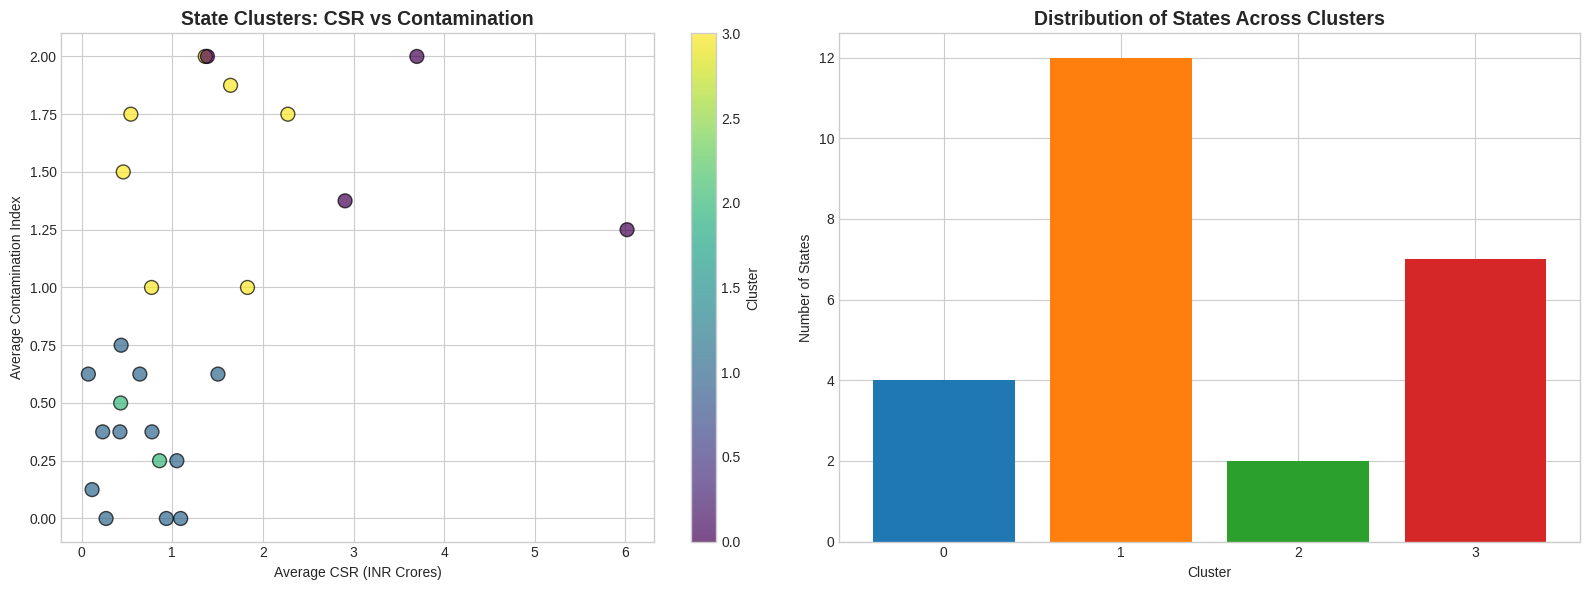

Cluster profiles:

Cluster 0 (4 states): ANDHRA PRADESH, KARNATAKA, MAHARASHTRA, TELANGANA
avg_csr_inr_crores              3.50
contamination_index             1.66
avg_institutions            35166.84
csr_per_capita_inr              0.49
institutions_per_million      569.70
dtype: float64

Cluster 1 (12 states): ARUNACHAL PRADESH, ASSAM, BIHAR, CHHATTISGARH, HIMACHAL PRADESH, JHARKHAND, KERALA, MEGHALAYA, NAGALAND, TRIPURA, UTTARAKHAND, WEST BENGAL
avg_csr_inr_crores             0.63
contamination_index            0.34
avg_institutions            3222.69
csr_per_capita_inr             0.44
institutions_per_million     125.43
dtype: float64

Cluster 2 (2 states): CHANDIGARH, GOA
avg_csr_inr_crores            0.64
contamination_index           0.38
avg_institutions            444.37
csr_per_capita_inr            4.44
institutions_per_million    312.05
dtype: float64

Cluster 3 (7 states): GUJARAT, HARYANA, MADHYA PRADESH, ODISHA, PUNJAB, RAJASTHAN, UTTAR PRADESH
avg_csr_inr_crores      

In [21]:
# Prepare data for clustering (state-level averages)
state_profile = df.groupby('state_name').agg({
    'avg_csr_inr_crores': 'mean',
    'contamination_index': 'mean',
    'avg_institutions': 'mean',
    'csr_per_capita_inr': 'mean',
    'institutions_per_million': 'mean'
}).reset_index().dropna()

features = ['avg_csr_inr_crores', 'contamination_index', 'avg_institutions',
            'csr_per_capita_inr', 'institutions_per_million']
X = state_profile[features]

# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# K-Means clustering
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
state_profile['cluster'] = kmeans.fit_predict(X_scaled)

# Visualize clusters
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Cluster scatter: CSR vs Contamination
scatter = axes[0].scatter(state_profile['avg_csr_inr_crores'],
                          state_profile['contamination_index'],
                          c=state_profile['cluster'], cmap='viridis', s=100, alpha=0.7, edgecolors='black')
axes[0].set_xlabel('Average CSR (INR Crores)')
axes[0].set_ylabel('Average Contamination Index')
axes[0].set_title('State Clusters: CSR vs Contamination', fontsize=14, fontweight='bold')
plt.colorbar(scatter, ax=axes[0], label='Cluster')

# Cluster sizes
cluster_counts = state_profile['cluster'].value_counts().sort_index()
axes[1].bar(cluster_counts.index, cluster_counts.values, color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'])
axes[1].set_xlabel('Cluster')
axes[1].set_ylabel('Number of States')
axes[1].set_title('Distribution of States Across Clusters', fontsize=14, fontweight='bold')
axes[1].set_xticks(range(4))

plt.tight_layout()
plt.savefig('/home/jovyan/work/clustering_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("Cluster profiles:")
for c in sorted(state_profile['cluster'].unique()):
    states = state_profile[state_profile['cluster'] == c]['state_name'].tolist()
    print(f"\nCluster {c} ({len(states)} states): {', '.join(states)}")
    print(state_profile[state_profile['cluster'] == c][features].mean().round(2))

## 3. Panel Regression Analysis

In [22]:
# Prepare panel data
panel_df = df[['state_name', 'year', 'contamination_index', 'csr_spent_lag1',
               'avg_institutions', 'avg_approved_intake', 'institutions_per_million']].dropna()

# Create dummy variables for fixed effects
panel_df = pd.get_dummies(panel_df, columns=['state_name', 'year'], drop_first=True)

# Define features and target
X_cols = [c for c in panel_df.columns if c not in ['contamination_index']]
y = panel_df['contamination_index']
X = panel_df[X_cols]

print(f"Panel regression sample: {len(panel_df)} observations")
print(f"Features: {len(X_cols)} (including fixed effects)")

Panel regression sample: 174 observations
Features: 34 (including fixed effects)


In [23]:
# Model 1: OLS with Fixed Effects
X_ols = sm.add_constant(X[['csr_spent_lag1', 'avg_institutions', 'institutions_per_million']])
ols_model = OLS(y, X_ols).fit()
print("=== OLS with Key Covariates ===")
print(ols_model.summary().tables[1])
print(f"\nR²: {ols_model.rsquared:.4f}, Adjusted R²: {ols_model.rsquared_adj:.4f}")
print(f"RMSE: {np.sqrt(ols_model.mse_resid):.4f}")

=== OLS with Key Covariates ===
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
const                        0.7428      0.072     10.265      0.000       0.600       0.886
csr_spent_lag1               0.0122      0.053      0.231      0.818      -0.092       0.117
avg_institutions          5.234e-06   3.23e-06      1.623      0.107   -1.13e-06    1.16e-05
institutions_per_million     0.0001      0.000      0.782      0.435      -0.000       0.000

R²: 0.0919, Adjusted R²: 0.0759
RMSE: 0.7903


=== Random Forest ===
R² (in-sample): 0.7884
RMSE (in-sample): 0.3770
RMSE (5-fold CV): 0.6812


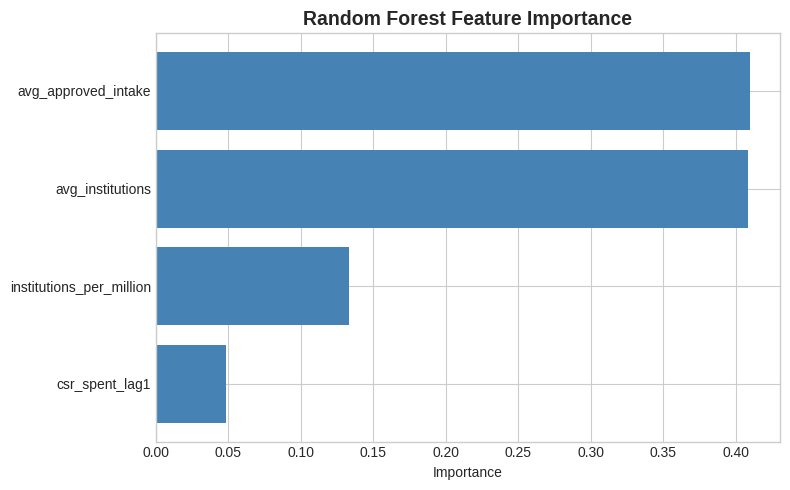

                    feature  importance
2       avg_approved_intake    0.409963
1          avg_institutions    0.408445
3  institutions_per_million    0.133197
0            csr_spent_lag1    0.048395


In [24]:
# Model 2: Random Forest
rf_features = ['csr_spent_lag1', 'avg_institutions', 'avg_approved_intake', 'institutions_per_million']
rf_X = panel_df[rf_features]

rf = RandomForestRegressor(n_estimators=100, random_state=42, max_depth=5)
rf.fit(rf_X, y)
rf_pred = rf.predict(rf_X)

rf_cv = cross_val_score(rf, rf_X, y, cv=5, scoring='neg_mean_squared_error')
rf_rmse_cv = np.sqrt(-rf_cv.mean())

print("=== Random Forest ===")
print(f"R² (in-sample): {r2_score(y, rf_pred):.4f}")
print(f"RMSE (in-sample): {np.sqrt(mean_squared_error(y, rf_pred)):.4f}")
print(f"RMSE (5-fold CV): {rf_rmse_cv:.4f}")

# Feature importance
feat_imp = pd.DataFrame({
    'feature': rf_features,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(8, 5))
plt.barh(feat_imp['feature'], feat_imp['importance'], color='steelblue')
plt.xlabel('Importance')
plt.title('Random Forest Feature Importance', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('/home/jovyan/work/rf_feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()
print(feat_imp)

=== XGBoost Gradient Boosting ===
R² (in-sample): 0.9556
RMSE (in-sample): 0.1728
RMSE (5-fold CV): 0.7219


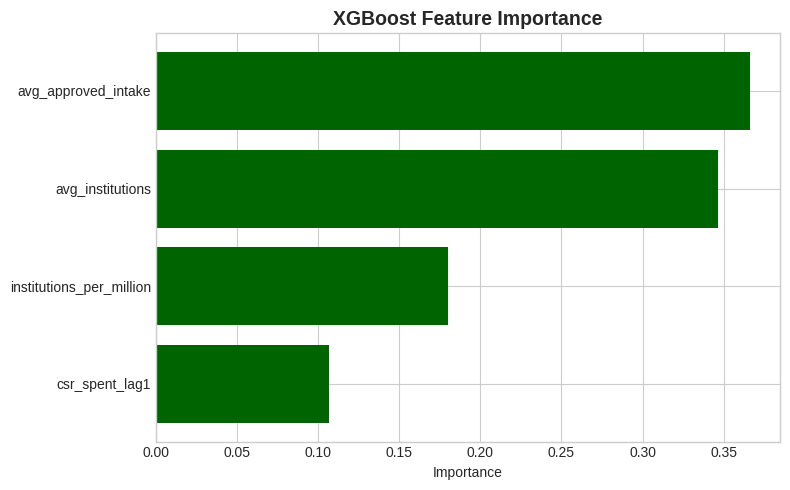

                    feature  importance
2       avg_approved_intake    0.366445
1          avg_institutions    0.346738
3  institutions_per_million    0.180073
0            csr_spent_lag1    0.106743


In [25]:
# Model 3: Gradient Boosting (XGBoost)
xgb_model = xgb.XGBRegressor(n_estimators=100, max_depth=4, learning_rate=0.1,
                              random_state=42, subsample=0.8)
xgb_model.fit(rf_X, y)
xgb_pred = xgb_model.predict(rf_X)

xgb_cv = cross_val_score(xgb_model, rf_X, y, cv=5, scoring='neg_mean_squared_error')
xgb_rmse_cv = np.sqrt(-xgb_cv.mean())

print("=== XGBoost Gradient Boosting ===")
print(f"R² (in-sample): {r2_score(y, xgb_pred):.4f}")
print(f"RMSE (in-sample): {np.sqrt(mean_squared_error(y, xgb_pred)):.4f}")
print(f"RMSE (5-fold CV): {xgb_rmse_cv:.4f}")

# Feature importance
xgb_imp = pd.DataFrame({
    'feature': rf_features,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(8, 5))
plt.barh(xgb_imp['feature'], xgb_imp['importance'], color='darkgreen')
plt.xlabel('Importance')
plt.title('XGBoost Feature Importance', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('/home/jovyan/work/xgb_feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()
print(xgb_imp)

In [26]:
# Model Comparison Summary
results = pd.DataFrame({
    'Model': ['OLS', 'Random Forest', 'XGBoost'],
    'R² (In-Sample)': [
        ols_model.rsquared,
        r2_score(y, rf_pred),
        r2_score(y, xgb_pred)
    ],
    'RMSE (In-Sample)': [
        np.sqrt(ols_model.mse_resid),
        np.sqrt(mean_squared_error(y, rf_pred)),
        np.sqrt(mean_squared_error(y, xgb_pred))
    ],
    'RMSE (5-Fold CV)': [
        np.nan,  # OLS CV not computed
        rf_rmse_cv,
        xgb_rmse_cv
    ]
})

print("\n=== Model Comparison Summary ===")
print(results.round(4))

# Save results
results.to_csv('/home/jovyan/data/gold/model_comparison.csv', index=False)
print("\nResults saved to data/gold/model_comparison.csv")


=== Model Comparison Summary ===
           Model  R² (In-Sample)  RMSE (In-Sample)  RMSE (5-Fold CV)
0            OLS          0.0919            0.7903               NaN
1  Random Forest          0.7884            0.3770            0.6812
2        XGBoost          0.9556            0.1728            0.7219

Results saved to data/gold/model_comparison.csv


## 4. Spatial Maps (Geopandas)

Loaded shapefile: /home/jovyan/data/india_states.shp


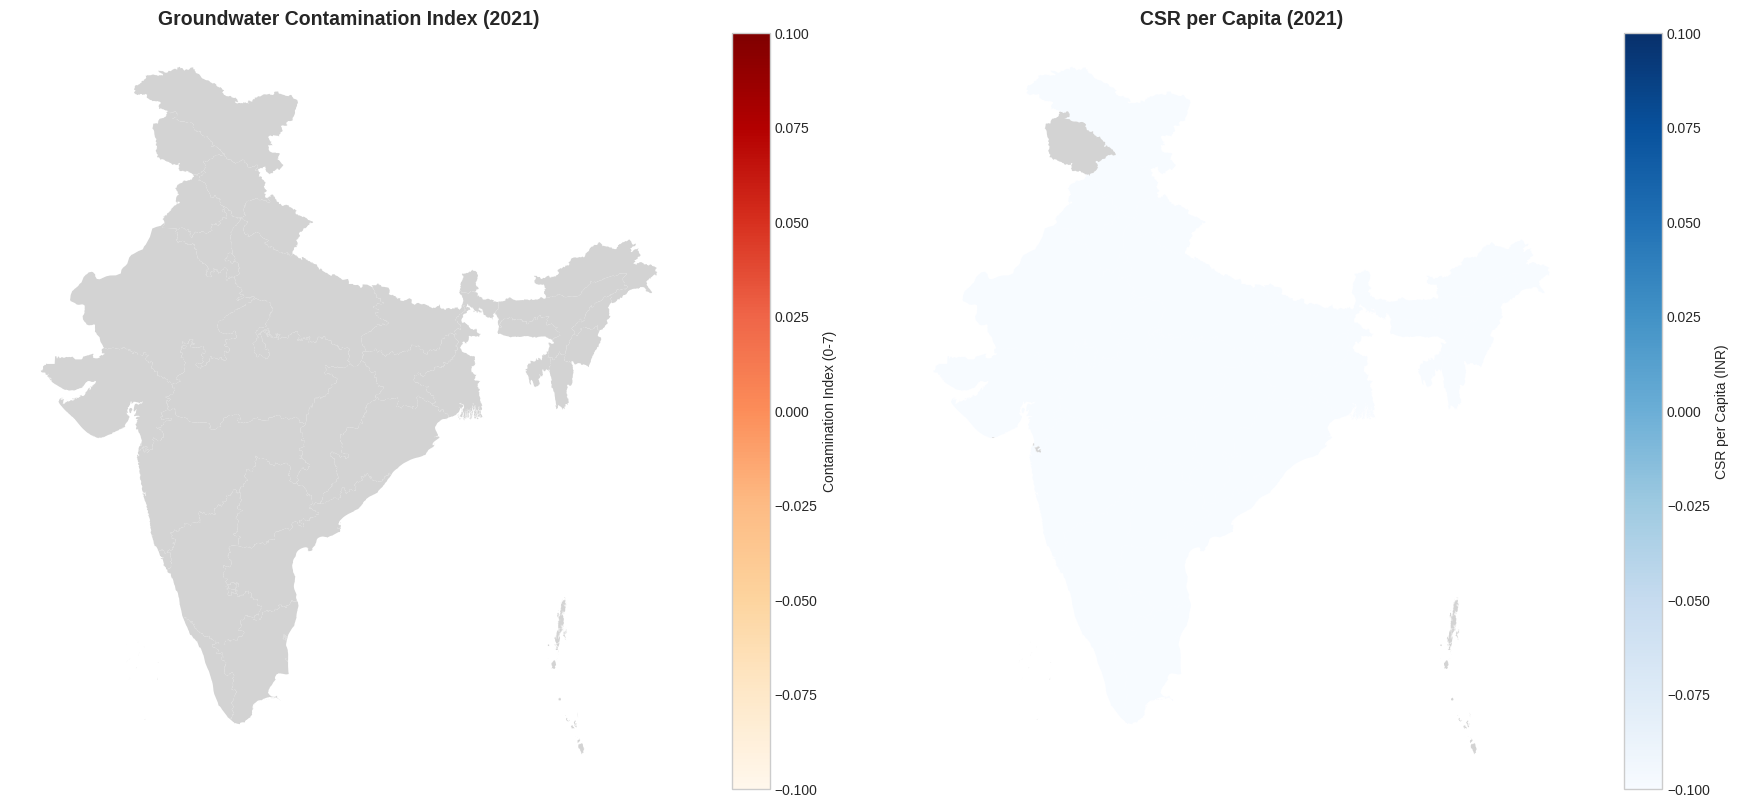

Choropleth maps saved to india_choropleth_maps.png


In [28]:
# Attempt to create choropleth maps
import os
try:
    import geopandas as gpd
    
    # Try to load India shapefile (common locations)
    shapefile_paths = [
        '/home/jovyan/data/india_states.shp',
        '/home/jovyan/data/IND_adm/IND_adm1.shp',
        '/home/jovyan/data/gadm41_IND_shp/gadm41_IND_1.shp'
    ]
    
    gdf = None
    for path in shapefile_paths:
        if os.path.exists(path):
            gdf = gpd.read_file(path)
            print(f"Loaded shapefile: {path}")
            break
    
    if gdf is not None:
        # Standardize state names in shapefile
        gdf['state_name'] = gdf['NAME_1'].str.upper() if 'NAME_1' in gdf.columns else gdf.iloc[:, 0].str.upper()
        
        # Merge with latest year data
        latest_year = df['year'].max()
        latest_df = df[df['year'] == latest_year][['state_name', 'contamination_index', 'csr_per_capita_inr']].copy()
        
        map_df = gdf.merge(latest_df, on='state_name', how='left')
        
        fig, axes = plt.subplots(1, 2, figsize=(18, 8))
        
        map_df.plot(column='contamination_index', cmap='OrRd', legend=True,
                    legend_kwds={'label': 'Contamination Index (0-7)'},
                    ax=axes[0], missing_kwds={'color': 'lightgrey'})
        axes[0].set_title(f'Groundwater Contamination Index ({latest_year})', fontsize=14, fontweight='bold')
        axes[0].axis('off')
        
        map_df.plot(column='csr_per_capita_inr', cmap='Blues', legend=True,
                    legend_kwds={'label': 'CSR per Capita (INR)'},
                    ax=axes[1], missing_kwds={'color': 'lightgrey'})
        axes[1].set_title(f'CSR per Capita ({latest_year})', fontsize=14, fontweight='bold')
        axes[1].axis('off')
        
        plt.tight_layout()
        plt.savefig('/home/jovyan/work/india_choropleth_maps.png', dpi=300, bbox_inches='tight')
        plt.show()
        print("Choropleth maps saved to india_choropleth_maps.png")
    else:
        print("No India shapefile found. Please download and place in data/ directory.")
        print("Using bar charts as spatial proxy instead (already generated above).")
except Exception as e:
    print(f"Geopandas error: {e}")
    print("Spatial analysis completed using bar charts above.")